##Project Notebook Link

https://colab.research.google.com/drive/1gBZGeX3PtJJHxP1YgZfqHIcwj1ed6PSM?usp=sharing

In [ ]:
#Linear Methods for classification – Project 1
# I will implement both data sets in the same notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, make_scorer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.manifold import TSNE

from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier


In [ ]:
#helper functions for both datasets
weighted_f1 = make_scorer(f1_score, average="weighted")

def check_missing_and_impute(df, strategy="median", zero_as_missing_cols=None):
    df = df.copy()

    # treat 0 as missing for specific columns (mainly diabetes)
    if zero_as_missing_cols:
        for col in zero_as_missing_cols:
            if col in df.columns:
                df[col] = df[col].replace(0, np.nan)

    print("Missing values per column:")
    print(df.isnull().sum())

    num_cols = df.select_dtypes(include=[np.number]).columns

    if strategy == "median":
        for col in num_cols:
            if df[col].isnull().any():
                df[col] = df[col].fillna(df[col].median())
    elif strategy == "mean":
        for col in num_cols:
            if df[col].isnull().any():
                df[col] = df[col].fillna(df[col].mean())
    else:
        raise ValueError("strategy must be 'median' or 'mean'")

    return df


def tsne_plot(X, y, title, perplexity=30, random_state=42):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(7,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=y, s=12)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()







In [ ]:
#load datasets
glass = pd.read_csv("glass.data", header=None)
diabetes = pd.read_csv("diabetes.csv")

print("Glass shape:", glass.shape)
print("Diabetes shape:", diabetes.shape)
print("Diabetes columns:", list(diabetes.columns))


FileNotFoundError: [Errno 2] No such file or directory: 'glass.data'

In [ ]:
#Glass dataset
glass.columns = ["Id","RI","Na","Mg","Al","Si","K","Ca","Ba","Fe","Class"]

Xg = glass.drop(columns=["Id","Class"])
yg = glass["Class"]

print(glass.head())


   Id       RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Class
0   1  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0      1
1   2  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0      1
2   3  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0      1
3   4  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0      1
4   5  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0      1


Missing values per column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Diabetes scaled range: 0.0 to 1.0000000000000002


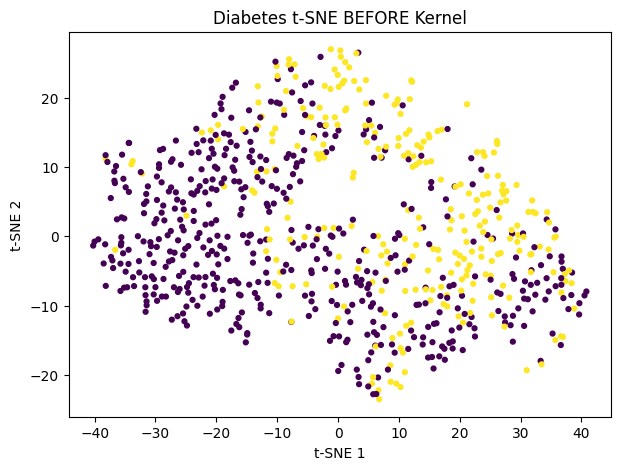

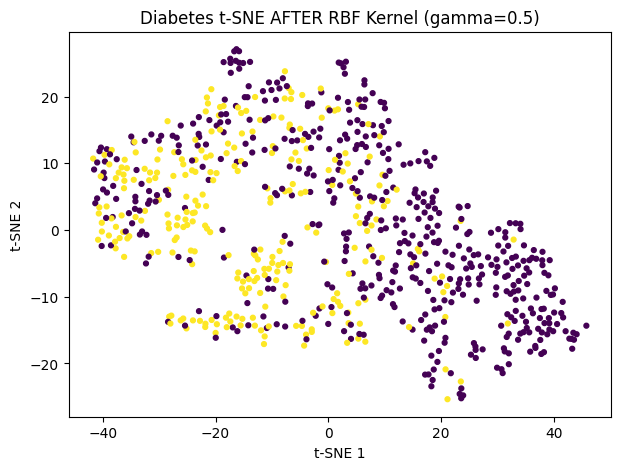

In [ ]:
#R1 – Diabetes dataset - preprocessing
#a) check missing values and impute
cols_zero_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

diabetes_clean = check_missing_and_impute(
    diabetes,
    strategy="median",
    zero_as_missing_cols=cols_zero_missing
)

# split features and label
Xd = diabetes_clean.drop(columns=["Outcome"])
yd = diabetes_clean["Outcome"]

#b) normalize to [0,1]
scaler_d = MinMaxScaler()
Xd_scaled = scaler_d.fit_transform(Xd)

print("Diabetes scaled range:", Xd_scaled.min(), "to", Xd_scaled.max())

#d) t-SNE BEFORE kernel
tsne_plot(Xd_scaled, yd, "Diabetes t-SNE BEFORE Kernel")

#c) apply RBF kernel
gamma_init = 0.5
Xd_kernel = rbf_kernel(Xd_scaled, gamma=gamma_init)

#d) t-SNE AFTER kernel
tsne_plot(Xd_kernel, yd, f"Diabetes t-SNE AFTER RBF Kernel (gamma={gamma_init})")


Missing values per column:
Id       0
RI       0
Na       0
Mg       0
Al       0
Si       0
K        0
Ca       0
Ba       0
Fe       0
Class    0
dtype: int64
Glass scaled range: 0.0 to 1.0


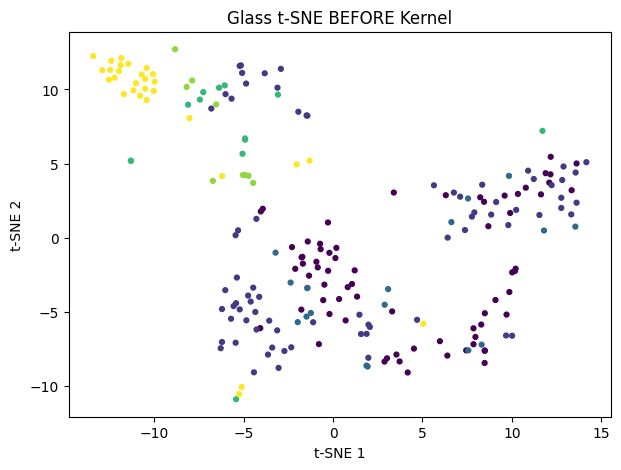

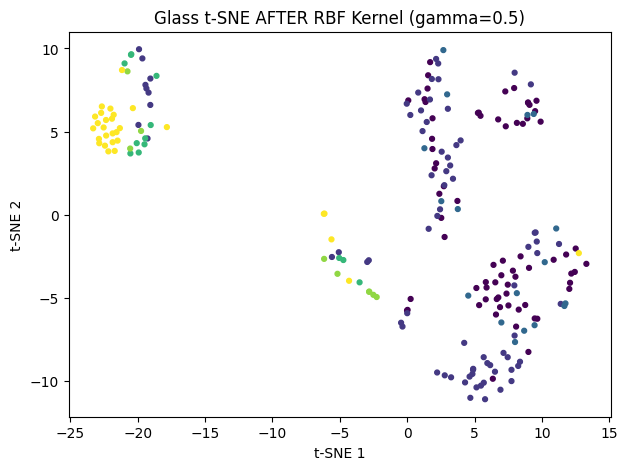

In [ ]:
#R1 Glass dataset - preprocessing
glass.columns = ["Id","RI","Na","Mg","Al","Si","K","Ca","Ba","Fe","Class"]

glass_clean = check_missing_and_impute(glass, strategy="median")

Xg = glass_clean.drop(columns=["Id","Class"])
yg = glass_clean["Class"]

scaler_g = MinMaxScaler()
Xg_scaled = scaler_g.fit_transform(Xg)

print("Glass scaled range:", Xg_scaled.min(), "to", Xg_scaled.max())

tsne_plot(Xg_scaled, yg, "Glass t-SNE BEFORE Kernel")

gamma_init = 0.5
Xg_kernel = rbf_kernel(Xg_scaled, gamma=gamma_init)

tsne_plot(Xg_kernel, yg, f"Glass t-SNE AFTER RBF Kernel (gamma={gamma_init})")

## R2 Model and training and tuning

In [ ]:
from sklearn.model_selection import train_test_split

# 70% train, 30% test (stratified)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg_scaled, yg, test_size=0.30, random_state=42, stratify=yg)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd_scaled, yd, test_size=0.30, random_state=42, stratify=yd)

print("Glass train/test:", Xg_tr.shape, Xg_te.shape)
print("Diabetes train/test:", Xd_tr.shape, Xd_te.shape)

Glass train/test: (149, 9) (65, 9)
Diabetes train/test: (537, 8) (231, 8)


In [ ]:
# hyperparameter grid for tuning linear models
param_grid = {
    "max_iter": [100, 500, 1000, 2000]
}

In [ ]:
#set up – cross validation and scoring
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import make_scorer, f1_score

weighted_f1 = make_scorer(f1_score, average="weighted")

# 5 folds repeated twice (reasonable and fast)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

## Glass Dataset


In [ ]:
#Glass - Perceptron tuning
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_iter": [100, 500, 1000, 2000]
}

perceptron = SGDClassifier(loss="perceptron", random_state=42)

grid_perc_glass = GridSearchCV(
    perceptron,
    param_grid,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_perc_glass.fit(Xg_scaled, yg)

print("Best max_iter (Glass Perceptron):", grid_perc_glass.best_params_)
print("Best weighted F1:", grid_perc_glass.best_score_)

Best max_iter (Glass Perceptron): {'max_iter': 100}
Best weighted F1: 0.40356155695125795


In [ ]:
#Glass – -Logistic Regression tuning
log_reg = SGDClassifier(loss="log_loss", random_state=42)

grid_log_glass = GridSearchCV(
    log_reg,
    param_grid,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_log_glass.fit(Xg_scaled, yg)

print("Best max_iter (Glass Logistic):", grid_log_glass.best_params_)
print("Best weighted F1:", grid_log_glass.best_score_)

Best max_iter (Glass Logistic): {'max_iter': 100}
Best weighted F1: 0.50652766397267


In [ ]:
#Glass – MLP tuning (grid search)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_mlp = {
    "max_iter": [300, 500, 1000],
    "n_iter_no_change": [10, 20]
}

grid_mlp_glass = GridSearchCV(
    MLPClassifier(random_state=42),
    param_mlp,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_mlp_glass.fit(Xg_tr, yg_tr)

print("Best Glass MLP params:", grid_mlp_glass.best_params_)
print("Best Glass MLP F1:", grid_mlp_glass.best_score_)

Best Glass MLP params: {'max_iter': 1000, 'n_iter_no_change': 10}
Best Glass MLP F1: 0.6252999777015874


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Diabetes Dataset

In [ ]:
#Diabetes – Perceptron tuning
grid_perc_diab = GridSearchCV(
    SGDClassifier(loss="perceptron", random_state=42),
    param_grid,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_perc_diab.fit(Xd_scaled, yd)

print("Best max_iter (Diabetes Perceptron):", grid_perc_diab.best_params_)
print("Best weighted F1:", grid_perc_diab.best_score_)

Best max_iter (Diabetes Perceptron): {'max_iter': 100}
Best weighted F1: 0.6317251360834986


In [ ]:
#Diabetes– Logistic tuning
grid_log_diab = GridSearchCV(
    SGDClassifier(loss="log_loss", random_state=42),
    param_grid,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_log_diab.fit(Xd_scaled, yd)

print("Best max_iter (Diabetes Logistic):", grid_log_diab.best_params_)
print("Best weighted F1:", grid_log_diab.best_score_)


Best max_iter (Diabetes Logistic): {'max_iter': 100}
Best weighted F1: 0.7364705308248272


In [ ]:
grid_mlp_diab = GridSearchCV(
    MLPClassifier(random_state=42),
    param_mlp,
    scoring=weighted_f1,
    cv=cv,
    n_jobs=-1
)

grid_mlp_diab.fit(Xd_tr, yd_tr)

print("Best Diabetes MLP params:", grid_mlp_diab.best_params_)
print("Best Diabetes MLP F1:", grid_mlp_diab.best_score_)

Best Diabetes MLP params: {'max_iter': 300, 'n_iter_no_change': 10}
Best Diabetes MLP F1: 0.7763167085922456


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## Gama tuning Diabetes and Glass


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.linear_model import SGDClassifier

gamma_values = [0.01, 0.1, 0.5, 1, 5]

def tune_gamma_after_kernel(X_train, y_train, loss_name, best_max_iter, label):
    best_gamma = None
    best_score = -1

    print(f"\n--- {label} | {loss_name} | best_max_iter={best_max_iter} ---")
    for g in gamma_values:
        Xk = rbf_kernel(X_train, gamma=g)
        model = SGDClassifier(loss=loss_name, max_iter=best_max_iter, random_state=42)

        scores = cross_val_score(model, Xk, y_train, scoring=weighted_f1, cv=cv)
        mean_score = scores.mean()
        print(f"gamma={g} -> weighted F1={mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_gamma = g

    print(f"BEST gamma={best_gamma}, weighted F1={best_score:.4f}")
    return best_gamma, best_score


# pull tuned max_iter from your GridSearch results
best_iter_glass_perc = grid_perc_glass.best_params_["max_iter"]
best_iter_glass_log  = grid_log_glass.best_params_["max_iter"]

best_iter_diab_perc = grid_perc_diab.best_params_["max_iter"]
best_iter_diab_log  = grid_log_diab.best_params_["max_iter"]

# GLASS
glass_perc_gamma, glass_perc_f1_after = tune_gamma_after_kernel(Xg_tr, yg_tr, "perceptron", best_iter_glass_perc, "GLASS")
glass_log_gamma,  glass_log_f1_after  = tune_gamma_after_kernel(Xg_tr, yg_tr, "log_loss",    best_iter_glass_log,  "GLASS")

# DIABETES
diab_perc_gamma, diab_perc_f1_after = tune_gamma_after_kernel(Xd_tr, yd_tr, "perceptron", best_iter_diab_perc, "DIABETES")
diab_log_gamma,  diab_log_f1_after  = tune_gamma_after_kernel(Xd_tr, yd_tr, "log_loss",    best_iter_diab_log,  "DIABETES")



--- GLASS | perceptron | best_max_iter=100 ---
gamma=0.01 -> weighted F1=0.1430
gamma=0.1 -> weighted F1=0.1766
gamma=0.5 -> weighted F1=0.3343
gamma=1 -> weighted F1=0.3512
gamma=5 -> weighted F1=0.5025
BEST gamma=5, weighted F1=0.5025

--- GLASS | log_loss | best_max_iter=100 ---
gamma=0.01 -> weighted F1=0.1576
gamma=0.1 -> weighted F1=0.1313
gamma=0.5 -> weighted F1=0.3140
gamma=1 -> weighted F1=0.3238
gamma=5 -> weighted F1=0.4800
BEST gamma=5, weighted F1=0.4800

--- DIABETES | perceptron | best_max_iter=100 ---
gamma=0.01 -> weighted F1=0.4033
gamma=0.1 -> weighted F1=0.6422
gamma=0.5 -> weighted F1=0.6595
gamma=1 -> weighted F1=0.6295
gamma=5 -> weighted F1=0.7122
BEST gamma=5, weighted F1=0.7122

--- DIABETES | log_loss | best_max_iter=100 ---
gamma=0.01 -> weighted F1=0.4138
gamma=0.1 -> weighted F1=0.6182
gamma=0.5 -> weighted F1=0.6336
gamma=1 -> weighted F1=0.6963
gamma=5 -> weighted F1=0.6571
BEST gamma=1, weighted F1=0.6963


In [ ]:
##Compare best of 4 vs MLP
import pandas as pd

results = pd.DataFrame([
    # GLASS (before kernel = GridSearch best_score_)
    ["Glass", "Perceptron (before kernel)", grid_perc_glass.best_score_],
    ["Glass", "Logistic (before kernel)",   grid_log_glass.best_score_],
    ["Glass", "Perceptron (after kernel)",  glass_perc_f1_after],
    ["Glass", "Logistic (after kernel)",    glass_log_f1_after],
    ["Glass", "MLP (tuned)",                grid_mlp_glass.best_score_],

    # DIABETES
    ["Diabetes", "Perceptron (before kernel)", grid_perc_diab.best_score_],
    ["Diabetes", "Logistic (before kernel)",   grid_log_diab.best_score_],
    ["Diabetes", "Perceptron (after kernel)",  diab_perc_f1_after],
    ["Diabetes", "Logistic (after kernel)",    diab_log_f1_after],
    ["Diabetes", "MLP (tuned)",                grid_mlp_diab.best_score_],
], columns=["Dataset", "Model", "Weighted F1 (CV on train 70%)"])

results

,Dataset,Model,Weighted F1 (CV on train 70%)
0,Glass,Perceptron (before kernel),0.403562
1,Glass,Logistic (before kernel),0.506528
2,Glass,Perceptron (after kernel),0.502508
3,Glass,Logistic (after kernel),0.480026
4,Glass,MLP (tuned),0.625300
5,Diabetes,Perceptron (before kernel),0.631725
6,Diabetes,Logistic (before kernel),0.736471
7,Diabetes,Perceptron (after kernel),0.712208
8,Diabetes,Logistic (after kernel),0.696288
9,Diabetes,MLP (tuned),0.776317


In [ ]:
##best model
def best_of_four(dataset):
    df = results[(results["Dataset"] == dataset) & (results["Model"] != "MLP (tuned)")]
    best_row = df.loc[df["Weighted F1 (CV on train 70%)"].idxmax()]
    return best_row["Model"], best_row["Weighted F1 (CV on train 70%)"]

best_glass_model, best_glass_f1 = best_of_four("Glass")
best_diab_model, best_diab_f1 = best_of_four("Diabetes")

print("GLASS: best of 4 =", best_glass_model, "| F1 =", best_glass_f1, "| MLP F1 =", results[(results.Dataset=="Glass") & (results.Model=="MLP (tuned)")]["Weighted F1 (CV on train 70%)"].values[0])
print("DIABETES: best of 4 =", best_diab_model, "| F1 =", best_diab_f1, "| MLP F1 =", results[(results.Dataset=="Diabetes") & (results.Model=="MLP (tuned)")]["Weighted F1 (CV on train 70%)"].values[0])


GLASS: best of 4 = Logistic (before kernel) | F1 = 0.50652766397267 | MLP F1 = 0.6252999777015874
DIABETES: best of 4 = Logistic (before kernel) | F1 = 0.7364705308248272 | MLP F1 = 0.7763167085922456


## Requirement 3 R3

In [ ]:
# best linear model
best_model_name = "Logistic Regression (SGD log_loss)"

best_iter_glass = grid_log_glass.best_params_["max_iter"]
best_iter_diab  = grid_log_diab.best_params_["max_iter"]

print("Best linear model:", best_model_name)
print("Best max_iter (Glass):", best_iter_glass)
print("Best max_iter (Diabetes):", best_iter_diab)

Best linear model: Logistic Regression (SGD log_loss)
Best max_iter (Glass): 100
Best max_iter (Diabetes): 100


In [ ]:
#t-SNE and deicison boundary
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.linear_model import SGDClassifier

def tsne_with_boundary(X_original, y, title, max_iter=1000, random_state=42, perplexity=30):
  #r3 – use oroginal feature space (X_original) to reate a 2D t-sne embedding
  #Train best linear model on the t-SNE coords (2D) and draw its deicision

  #t-SNE embedding
  tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, init="pca", learning_rate="auto")
  X2 = tsne.fit_transform(X_original)

    # 2) Train best linear model on the 2D t-SNE space
  clf = SGDClassifier(loss="log_loss", random_state=random_state, max_iter=max_iter)
  clf.fit(X2, y)

    # 3) Create mesh grid to draw decision boundary
  x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
  y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

  xx, yy = np.meshgrid(
      np.linspace(x_min, x_max, 400),
      np.linspace(y_min, y_max, 400)
    )

  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # 4) Plot
  plt.figure(figsize=(8, 6))
  plt.contourf(xx, yy, Z, alpha=0.25)

  # scatter points
  plt.scatter(X2[:, 0], X2[:, 1], c=y, s=18)
  plt.title(title)
  plt.xlabel("t-SNE 1")
  plt.ylabel("t-SNE 2")
  plt.show()
  return X2, clf


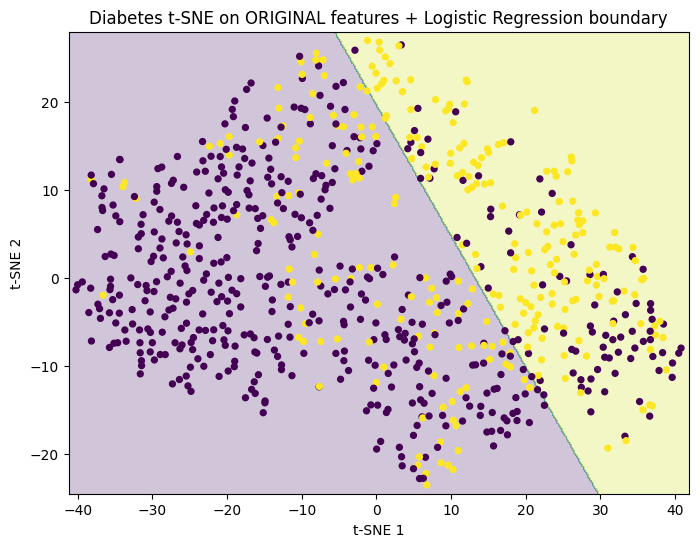

In [ ]:
#diabetes: t-SNE, boundary on original features
X2_diab, clf_diab = tsne_with_boundary(
    X_original=Xd_scaled,     # original features (scaled)
    y=yd,
    title="Diabetes t-SNE on ORIGINAL features + Logistic Regression boundary",
    max_iter=best_iter_diab,
    perplexity=30
)

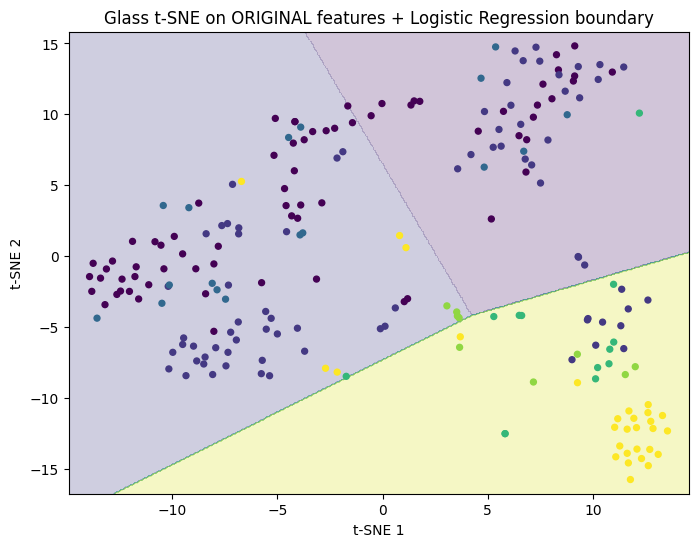

In [ ]:
#Glass– t-SNE, boundary on original features
X2_glass, clf_glass = tsne_with_boundary(
    X_original=Xg_scaled,
    y=yg,
    title="Glass t-SNE on ORIGINAL features + Logistic Regression boundary",
    max_iter=best_iter_glass,
    perplexity=25  # glass is smaller, 25 often works better
)

##R4


In [ ]:
#Logistic Regression ** no kernel**
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

# Glass
log_glass_r4 = SGDClassifier(loss="log_loss", class_weight=None, random_state=42)
log_glass_r4.fit(Xg_tr, yg_tr)

yg_pred = log_glass_r4.predict(Xg_te)
glass_f1_full = f1_score(yg_te, yg_pred, average="weighted")

print("Glass weighted F1 (all features):", glass_f1_full)

# Diabetes
log_diab_r4 = SGDClassifier(loss="log_loss", class_weight=None, random_state=42)
log_diab_r4.fit(Xd_tr, yd_tr)

yd_pred = log_diab_r4.predict(Xd_te)
diab_f1_full = f1_score(yd_te, yd_pred, average="weighted")

print("Diabetes weighted F1 (all features):", diab_f1_full)

Glass weighted F1 (all features): 0.4312054244671867
Diabetes weighted F1 (all features): 0.6926117360899969


In [ ]:
#Feature importance via coefficients
import numpy as np
import pandas as pd

def show_importance(model, feature_names, label):
    coefs = np.abs(model.coef_).mean(axis=0)
    df = pd.DataFrame({
        "feature": feature_names,
        "importance": coefs
    }).sort_values("importance", ascending=False)

    print(f"\n--- {label} MOST important ---")
    print(df.head(5))

    print(f"\n--- {label} LEAST important ---")
    print(df.tail(5))

    return df

# Glass feature names
glass_features = list(glass_clean.drop(columns=["Id","Class"]).columns)

# Diabetes feature names
diab_features = list(diabetes_clean.drop(columns=["Outcome"]).columns)

glass_imp = show_importance(log_glass_r4, glass_features, "GLASS")
diab_imp = show_importance(log_diab_r4, diab_features, "DIABETES")


--- GLASS MOST important ---
  feature  importance
1      Na    9.452957
3      Al    8.544469
2      Mg    7.419181
7      Ba    6.384269
4      Si    5.948206

--- GLASS LEAST important ---
  feature  importance
4      Si    5.948206
0      RI    5.053027
6      Ca    4.227986
5       K    4.107111
8      Fe    3.617941

--- DIABETES MOST important ---
                    feature  importance
1                   Glucose    6.854282
5                       BMI    5.793869
0               Pregnancies    2.689183
6  DiabetesPedigreeFunction    2.158739
3             SkinThickness    1.240798

--- DIABETES LEAST important ---
                    feature  importance
6  DiabetesPedigreeFunction    2.158739
3             SkinThickness    1.240798
2             BloodPressure    0.479410
7                       Age    0.442182
4                   Insulin    0.116195


In [ ]:
#Drop least important features
glass_drop = glass_imp.tail(5)["feature"].tolist()
diab_drop = diab_imp.tail(5)["feature"].tolist()

print("Drop Glass:", glass_drop)
print("Drop Diabetes:", diab_drop)

# Glass reduced
Xg_tr_red = pd.DataFrame(Xg_tr, columns=glass_features).drop(columns=glass_drop).values
Xg_te_red = pd.DataFrame(Xg_te, columns=glass_features).drop(columns=glass_drop).values

log_glass_red = SGDClassifier(loss="log_loss", random_state=42)
log_glass_red.fit(Xg_tr_red, yg_tr)

glass_red_f1 = f1_score(yg_te, log_glass_red.predict(Xg_te_red), average="weighted")
print("Glass F1 after dropping:", glass_red_f1)

# Diabetes reduced
Xd_tr_red = pd.DataFrame(Xd_tr, columns=diab_features).drop(columns=diab_drop).values
Xd_te_red = pd.DataFrame(Xd_te, columns=diab_features).drop(columns=diab_drop).values

log_diab_red = SGDClassifier(loss="log_loss", random_state=42)
log_diab_red.fit(Xd_tr_red, yd_tr)

diab_red_f1 = f1_score(yd_te, log_diab_red.predict(Xd_te_red), average="weighted")
print("Diabetes F1 after dropping:", diab_red_f1)


Drop Glass: ['Si', 'RI', 'Ca', 'K', 'Fe']
Drop Diabetes: ['DiabetesPedigreeFunction', 'SkinThickness', 'BloodPressure', 'Age', 'Insulin']
Glass F1 after dropping: 0.5461908097973671
Diabetes F1 after dropping: 0.7208093111707569


##R5


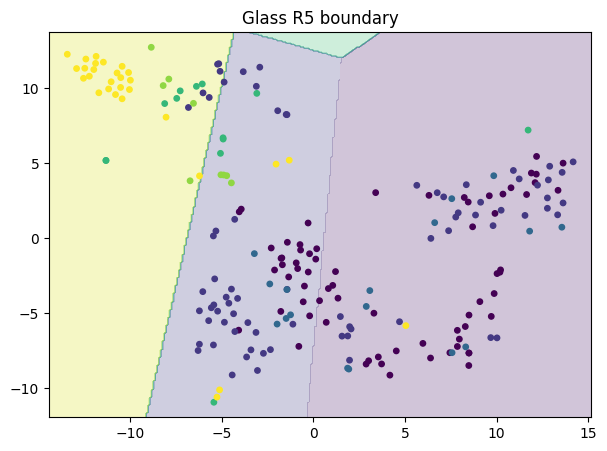

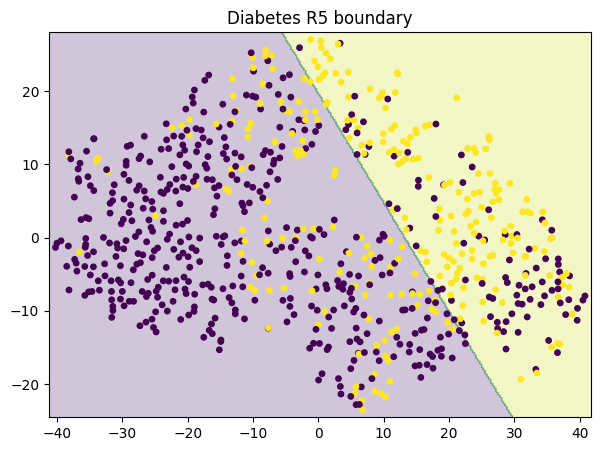

In [ ]:
## tSNE boundary visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def tsne_boundary(X, y, title):
    X2 = TSNE(n_components=2, random_state=42).fit_transform(X)

    clf = SGDClassifier(loss="log_loss", random_state=42)
    clf.fit(X2, y)

    x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
    y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X2[:,0], X2[:,1], c=y, s=15)
    plt.title(title)
    plt.show()

# Glass
tsne_boundary(Xg_scaled, yg, "Glass R5 boundary")

# Diabetes
tsne_boundary(Xd_scaled, yd, "Diabetes R5 boundary")